# Notebook 08 — Real L1 Data Analysis & Empirical Backtesting (BTC + ETH)

**Inputs**: Calibrated parameters, mid-prices, and **interval tables** from Notebook 11
(Tardis L1 `book_snapshot_5` + `trades` pipeline).

| Part | Content |
|------|---------|
| **A** | Data exploration: price, returns, volatility, spread distribution, intraday diagnostics |
| **B** | Empirical backtest on real L1 data: fill detection from aggressive trade flow |
| **C** | Real L1 fills vs synthetic Poisson fills: does the simulation match reality? |
| **D** | Rolling multi-window backtest: stability across market regimes |
| **E** | Summary metrics + dashboard-ready exports |

### Methodology

The empirical fill engine uses L1 trade extremes: a hypothetical quote at
$\text{mid} \pm \delta$ is filled if and only if a real aggressive trade
reached that price during the interval.  This ignores queue priority,
partial fills, and within-interval event ordering — acceptable
approximations for a coursework-level analysis that are stated explicitly.

Fills are **deterministic** given the data and the strategy — no Poisson
random draws.  Evaluation randomness comes from testing across many real
windows (Part D).

### Important data note

The Tardis free-tier data consists of **six isolated days** (1st of each
month, Oct 2024 – Mar 2025).  These are **not** consecutive — there are
month-long gaps between sessions.  All returns, rolling statistics, and
intraday diagnostics are computed **within each session** to avoid
spurious cross-session artifacts.

## 0. Imports and Data Loading

In [36]:
import json
import time
import pickle
import warnings
from pathlib import Path
from dataclasses import dataclass, field

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.stats import norm, kurtosis, skew

import sys
sys.path.append(str(Path().resolve().parents[0]))

from market_making.core.solver_1d import solve_general
from market_making.core.closed_form import approx_quotes
from market_making.core.intensity import C_coeff, fill_prob, Lambda

warnings.filterwarnings("ignore", category=FutureWarning)
plt.style.use("seaborn-v0_8")
%matplotlib inline

In [37]:
# ── Paths ────────────────────────────────────────────────────
ROOT = Path.cwd().parents[0]
DATA_DIR = ROOT / "data/data/calibrated"
CKPT_DIR = DATA_DIR / "checkpoints_tardis"
PARAMS_FILE = DATA_DIR / "calibrated_params.json"

SYMBOLS = ["BTCUSDT", "ETHUSDT"]
DEFAULT_GAMMA = 0.01  # crypto-scale gamma

# ── Load calibrated parameters ───────────────────────────────
assert PARAMS_FILE.exists(), f"Run Notebook 11 first -- {PARAMS_FILE} not found"

with open(PARAMS_FILE) as f:
    raw_params = json.load(f)

all_params = {}
all_mid = {}
all_intervals = {}

for symbol in SYMBOLS:
    cal = raw_params[symbol]
    all_params[symbol] = {
        "sigma": cal["sigma"], "A": cal["A"], "k": cal["k"],
        "Delta": cal["Delta"], "Q": cal.get("Q", 4),
        "lot_size": cal["lot_size"],   # quantity of asset per lot
    }

    # Load mid-prices
    mid_file = DATA_DIR / f"mid_prices_{symbol}.parquet"
    assert mid_file.exists(), f"Missing {mid_file}"
    all_mid[symbol] = pd.read_parquet(mid_file)["mid_price"]

    # Load interval tables from checkpoint (built by Notebook 11)
    ckpt_file = CKPT_DIR / f"{symbol}_mle.pkl"
    if ckpt_file.exists():
        with open(ckpt_file, "rb") as f:
            ckpt = pickle.load(f)
        all_intervals[symbol] = pd.concat(ckpt["interval_tables"], ignore_index=True)
    else:
        print(f"  WARNING: no checkpoint for {symbol}")

print(f"{'='*65}")
print(f"  Calibrated Parameters (Notebook 11, Tardis L1)")
print(f"{'='*65}")
for symbol in SYMBOLS:
    p = all_params[symbol]
    cal = raw_params[symbol]
    mid = all_mid[symbol]
    n_int = len(all_intervals.get(symbol, []))
    print(f"\n  {symbol}")
    print(f"    sigma    = {p['sigma']:.6f}  $/sqrt(s)")
    print(f"    A        = {p['A']:.6f}  1/s")
    print(f"    k        = {p['k']:.6f}  1/$")
    print(f"    Delta    = {p['Delta']:.2f}  $ (notional per lot)")
    print(f"    lot_size = {p['lot_size']}  (asset qty per lot)")
    print(f"    Q        = {p['Q']}  lots")
    print(f"    R2       = {cal.get('r_squared', '?')}")
    print(f"    Mid:       {len(mid):,} pts, ${mid.min():,.2f} -- ${mid.max():,.2f}")
    print(f"    Intervals: {n_int:,}")

  Calibrated Parameters (Notebook 11, Tardis L1)

  BTCUSDT
    sigma    = 5.015861  $/sqrt(s)
    A        = 0.646151  1/s
    k        = 0.491463  1/$
    Delta    = 85.07  $ (notional per lot)
    lot_size = 0.001  (asset qty per lot)
    Q        = 4  lots
    R2       = 0.3347
    Mid:       518,350 pts, $60,133.35 -- $102,734.85
    Intervals: 7,829,659

  ETHUSDT
    sigma    = 0.269903  $/sqrt(s)
    A        = 0.923777  1/s
    k        = 9.688005  1/$
    Delta    = 29.33  $ (notional per lot)
    lot_size = 0.01  (asset qty per lot)
    Q        = 4  lots
    R2       = 0.7359
    Mid:       518,344 pts, $2,142.51 -- $3,749.99
    Intervals: 8,405,829


---
# Part A — Data Exploration

**Critical**: our data consists of six isolated daily sessions.  All return-based
statistics must be computed **within** each session to avoid spurious jumps at
month boundaries.

In [38]:
# ── Session-aware helper functions ─────────────────────────────

def returns_by_session(mid: pd.Series) -> pd.Series:
    '''Compute 1s returns within each day-session, avoiding cross-session gaps.'''
    df = mid.to_frame("mid")
    df["session"] = df.index.date
    r = df.groupby("session")["mid"].diff()
    return r.dropna()


def hourly_sigma_by_session(mid: pd.Series) -> pd.Series:
    '''Hourly sigma computed within each session, then averaged across sessions.'''
    df = mid.to_frame("mid")
    df["session"] = df.index.date
    df["ret"] = df.groupby("session")["mid"].diff()
    df = df.dropna(subset=["ret"])
    return df.groupby(df.index.hour)["ret"].std()


def rolling_sigma_by_session(mid: pd.Series, window: int = 300) -> pd.Series:
    '''Rolling sigma computed within each session (never crosses session gaps).'''
    df = mid.to_frame("mid")
    df["session"] = df.index.date
    out = []
    for _, g in df.groupby("session"):
        r = g["mid"].diff()
        rs = r.rolling(window).std()
        out.append(rs)
    return pd.concat(out).dropna().sort_index()


print("Session-aware helpers defined.")

Session-aware helpers defined.


### A1. Full price series and half-spread distribution

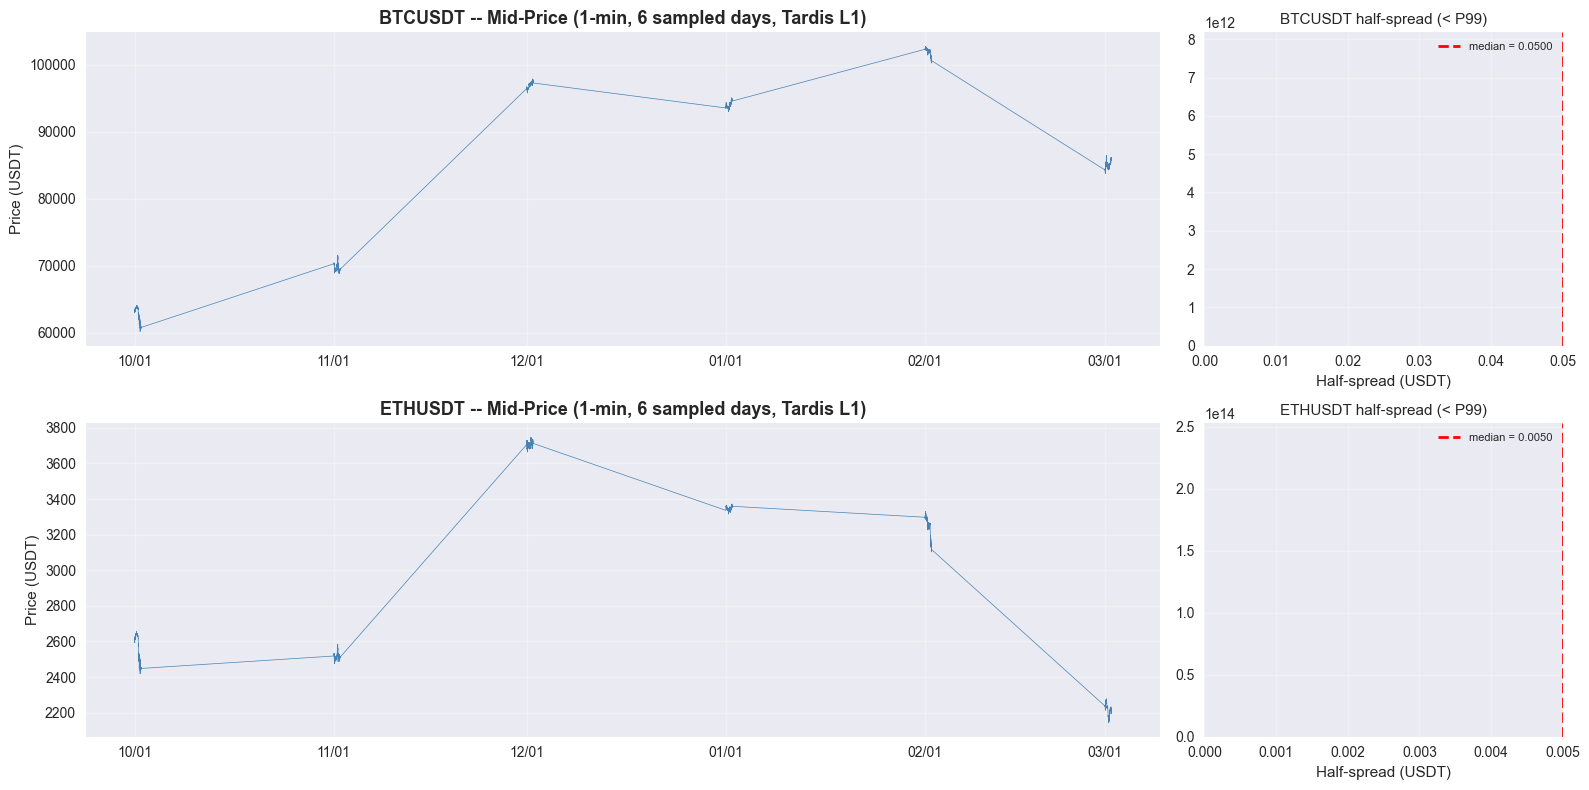

In [39]:
fig, axes = plt.subplots(len(SYMBOLS), 2, figsize=(16, 4 * len(SYMBOLS)),
                         gridspec_kw={"width_ratios": [3, 1]})
if len(SYMBOLS) == 1:
    axes = axes.reshape(1, 2)

for row, symbol in enumerate(SYMBOLS):
    mid = all_mid[symbol]
    mid_1min = mid.resample("1min").mean().dropna()

    ax = axes[row, 0]
    ax.plot(mid_1min.index, mid_1min.values, lw=0.5, color="steelblue")
    n_days = raw_params[symbol].get("n_days", "?")
    ax.set_title(f"{symbol} -- Mid-Price (1-min, {n_days} sampled days, Tardis L1)",
                 fontsize=13, fontweight="bold")
    ax.set_ylabel("Price (USDT)")
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m/%d"))

    # Half-spread distribution (capped at P99 for readability)
    ax = axes[row, 1]
    if symbol in all_intervals:
        hs = all_intervals[symbol]["half_spread"].dropna()
        cap = hs.quantile(0.99)
        hs_plot = hs[hs <= cap]
        ax.hist(hs_plot, bins=100, density=True, alpha=0.7, color="darkorange")
        ax.axvline(hs.median(), color="red", ls="--", lw=2,
                   label=f"median = {hs.median():.4f}")
        ax.set_title(f"{symbol} half-spread (< P99)", fontsize=11)
        ax.set_xlabel("Half-spread (USDT)")
        ax.set_xlim(0, cap)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### A2. Return distribution vs Gaussian

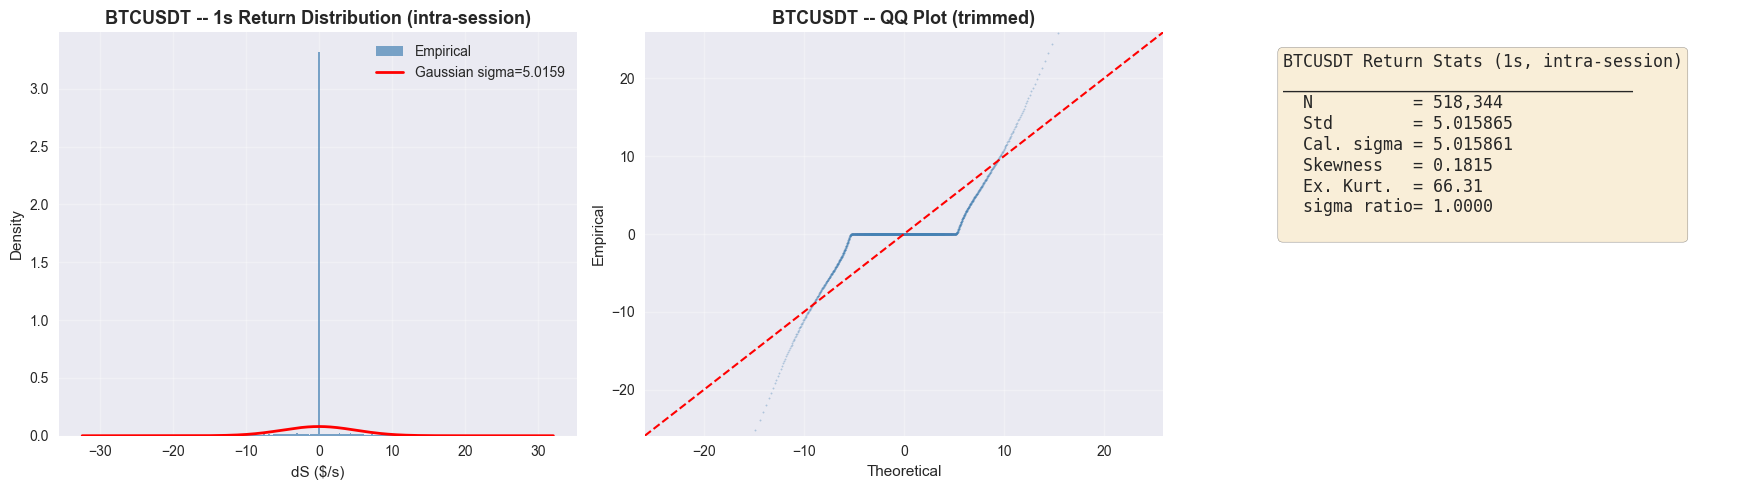

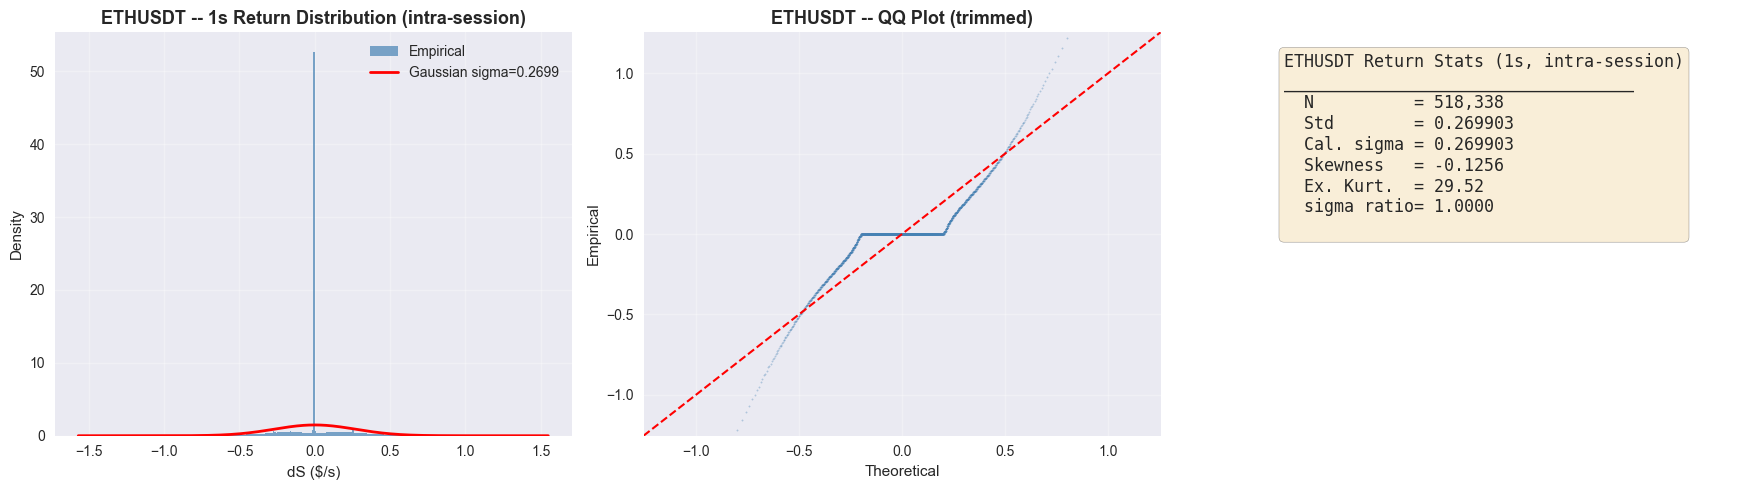

In [40]:
for symbol in SYMBOLS:
    mid = all_mid[symbol]
    sigma = all_params[symbol]["sigma"]
    returns_1s = returns_by_session(mid)

    q_lo, q_hi = returns_1s.quantile([0.001, 0.999])
    returns_trimmed = returns_1s[(returns_1s > q_lo) & (returns_1s < q_hi)]

    fig, axes_r = plt.subplots(1, 3, figsize=(18, 5))

    # Histogram
    ax = axes_r[0]
    ax.hist(returns_trimmed, bins=300, density=True, alpha=0.7, color="steelblue",
            label="Empirical")
    x_g = np.linspace(q_lo, q_hi, 500)
    ax.plot(x_g, norm.pdf(x_g, 0, sigma), "r-", lw=2,
            label=f"Gaussian sigma={sigma:.4f}")
    ax.set_title(f"{symbol} -- 1s Return Distribution (intra-session)",
                 fontsize=13, fontweight="bold")
    ax.set_xlabel("dS ($/s)")
    ax.set_ylabel("Density")
    ax.legend()
    ax.grid(True, alpha=0.3)

    # QQ plot (trimmed to P0.1 -- P99.9 for readability)
    ax = axes_r[1]
    qq_sample = returns_1s[(returns_1s >= q_lo) & (returns_1s <= q_hi)].values
    sorted_r = np.sort(qq_sample)
    n = len(sorted_r)
    theoretical = norm.ppf(np.linspace(1/(n+1), n/(n+1), n), 0, sigma)
    step = max(1, n // 2000)
    ax.scatter(theoretical[::step], sorted_r[::step], s=1, alpha=0.3, color="steelblue")
    lim = max(abs(theoretical[::step]).max(), abs(sorted_r[::step]).max()) * 0.8
    ax.plot([-lim, lim], [-lim, lim], "r--", lw=1.5)
    ax.set_title(f"{symbol} -- QQ Plot (trimmed)", fontsize=13, fontweight="bold")
    ax.set_xlabel("Theoretical")
    ax.set_ylabel("Empirical")
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)

    # Stats
    ax = axes_r[2]
    ax.axis("off")
    kurt_val = kurtosis(returns_1s.dropna())
    skew_val = skew(returns_1s.dropna())
    stats_text = (
        f"{symbol} Return Stats (1s, intra-session)\n"
        f"{'_'*35}\n"
        f"  N          = {len(returns_1s):,}\n"
        f"  Std        = {returns_1s.std():.6f}\n"
        f"  Cal. sigma = {sigma:.6f}\n"
        f"  Skewness   = {skew_val:.4f}\n"
        f"  Ex. Kurt.  = {kurt_val:.2f}\n"
        f"  sigma ratio= {returns_1s.std()/sigma:.4f}\n"
    )
    ax.text(0.1, 0.95, stats_text, transform=ax.transAxes, fontsize=12,
            verticalalignment="top", fontfamily="monospace",
            bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))

    plt.tight_layout()
    plt.show()

### A3. Indicative hourly volatility profile

Using the six sampled Tardis sessions, we compute an indicative hourly
volatility profile.  Given the sparse sampling scheme (one day per month),
this should be interpreted as a **descriptive diagnostic** rather than a
stable intraday seasonality estimate.

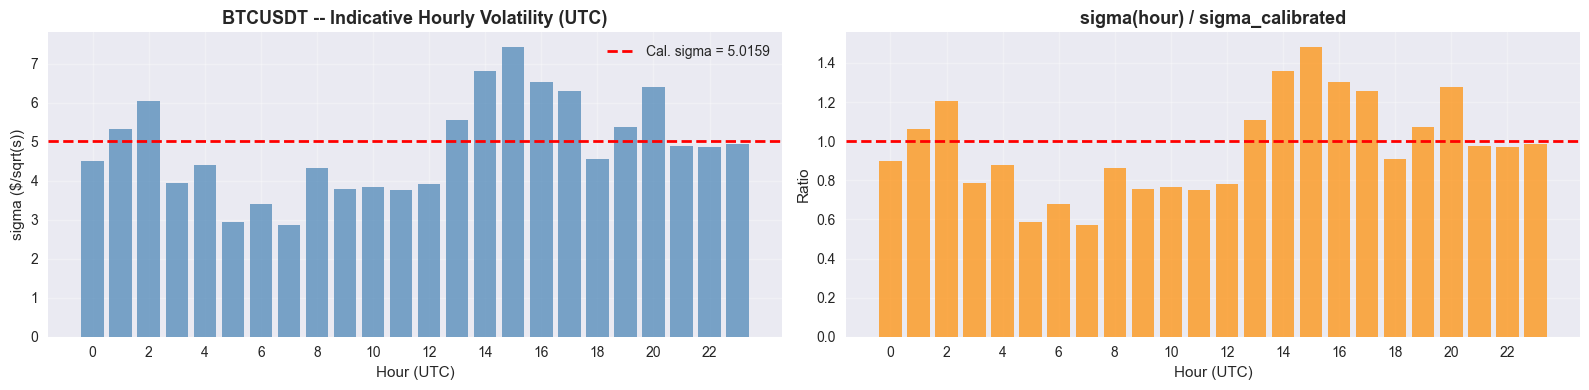

  BTCUSDT: peak at 15:00 (1.5x), trough at 7:00 (0.6x)


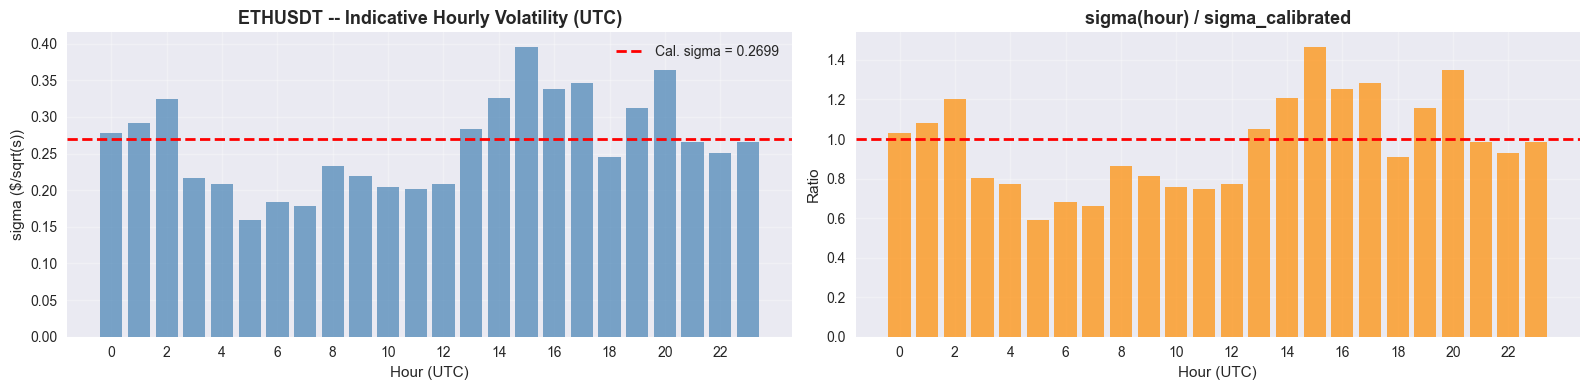

  ETHUSDT: peak at 15:00 (1.5x), trough at 5:00 (0.6x)


In [41]:
for symbol in SYMBOLS:
    mid = all_mid[symbol]
    sigma = all_params[symbol]["sigma"]
    hourly_sigma = hourly_sigma_by_session(mid)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))

    ax1.bar(hourly_sigma.index, hourly_sigma.values, alpha=0.7, color="steelblue")
    ax1.axhline(sigma, color="red", ls="--", lw=2, label=f"Cal. sigma = {sigma:.4f}")
    ax1.set_title(f"{symbol} -- Indicative Hourly Volatility (UTC)",
                  fontsize=13, fontweight="bold")
    ax1.set_xlabel("Hour (UTC)")
    ax1.set_ylabel("sigma ($/sqrt(s))")
    ax1.set_xticks(range(0, 24, 2))
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.bar(hourly_sigma.index, hourly_sigma.values / sigma, alpha=0.7, color="darkorange")
    ax2.axhline(1, color="red", ls="--", lw=2)
    ax2.set_title("sigma(hour) / sigma_calibrated", fontsize=13, fontweight="bold")
    ax2.set_xlabel("Hour (UTC)")
    ax2.set_ylabel("Ratio")
    ax2.set_xticks(range(0, 24, 2))
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    peak = hourly_sigma.idxmax()
    trough = hourly_sigma.idxmin()
    print(f"  {symbol}: peak at {peak}:00 ({hourly_sigma.max()/sigma:.1f}x), "
          f"trough at {trough}:00 ({hourly_sigma.min()/sigma:.1f}x)")

### A4. Autocorrelation of returns and |returns|

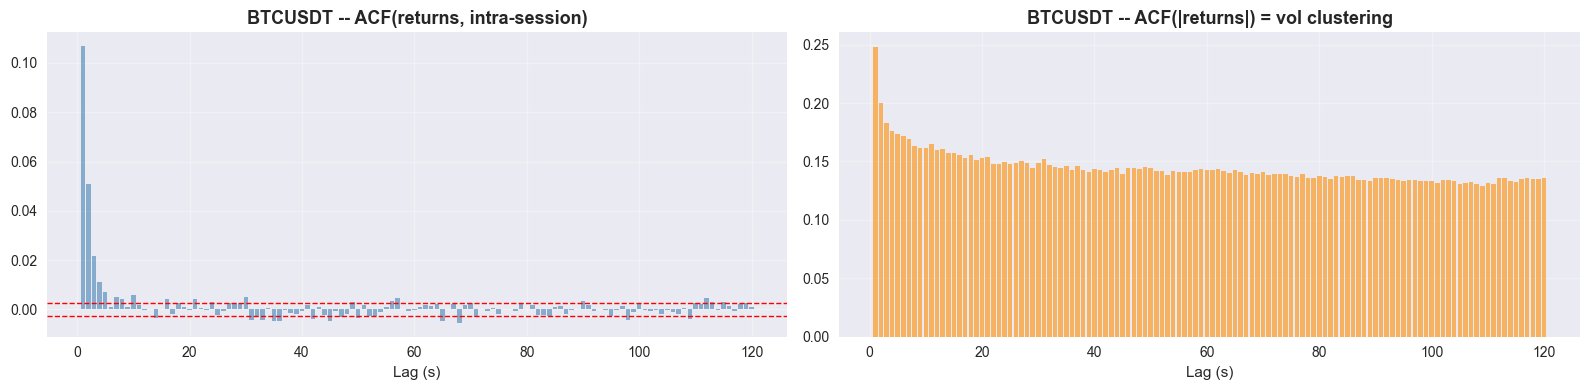

  BTCUSDT: ACF(r,1)=0.1068, ACF(|r|,1)=0.2481


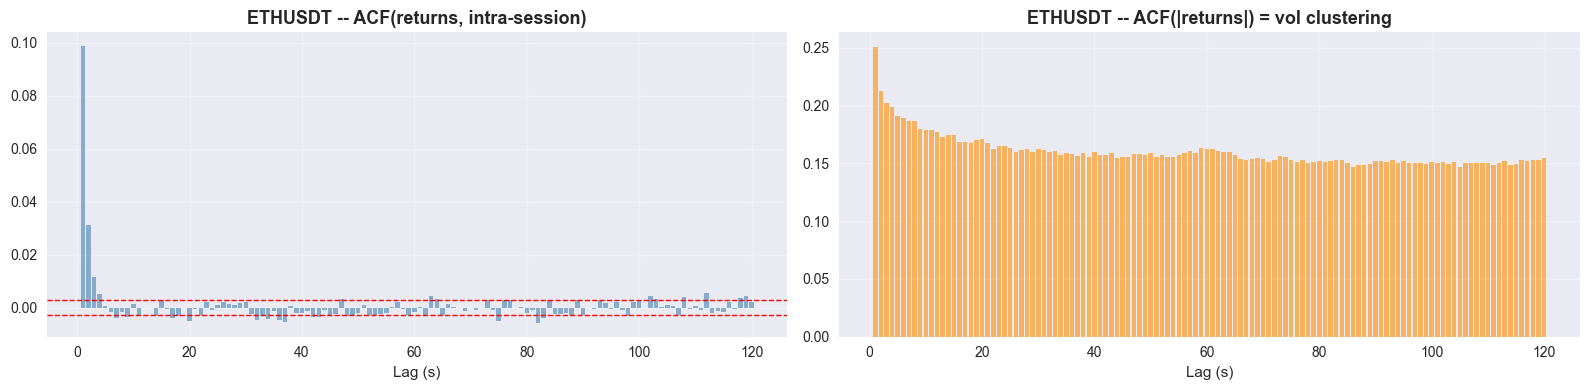

  ETHUSDT: ACF(r,1)=0.0988, ACF(|r|,1)=0.2508


In [42]:
max_lag = 120

for symbol in SYMBOLS:
    mid = all_mid[symbol]
    r_vals = returns_by_session(mid).values

    acf_r = [np.corrcoef(r_vals[:-lag], r_vals[lag:])[0, 1] for lag in range(1, max_lag + 1)]
    abs_r = np.abs(r_vals)
    acf_abs = [np.corrcoef(abs_r[:-lag], abs_r[lag:])[0, 1] for lag in range(1, max_lag + 1)]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))

    ax1.bar(range(1, max_lag + 1), acf_r, alpha=0.6, color="steelblue")
    ax1.axhline(1.96/np.sqrt(len(r_vals)), color="red", ls="--", lw=1)
    ax1.axhline(-1.96/np.sqrt(len(r_vals)), color="red", ls="--", lw=1)
    ax1.set_title(f"{symbol} -- ACF(returns, intra-session)", fontsize=13, fontweight="bold")
    ax1.set_xlabel("Lag (s)")
    ax1.grid(True, alpha=0.3)

    ax2.bar(range(1, max_lag + 1), acf_abs, alpha=0.6, color="darkorange")
    ax2.set_title(f"{symbol} -- ACF(|returns|) = vol clustering", fontsize=13, fontweight="bold")
    ax2.set_xlabel("Lag (s)")
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"  {symbol}: ACF(r,1)={acf_r[0]:.4f}, ACF(|r|,1)={acf_abs[0]:.4f}")

### A5. Rolling volatility (5-min windows, intra-session)

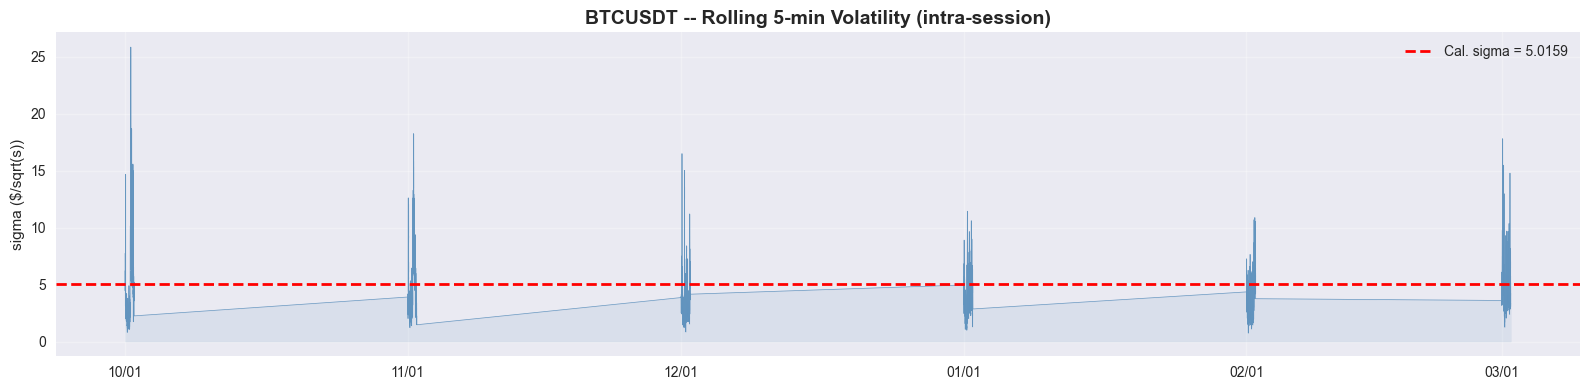

  BTCUSDT: 3.3% > 2x cal., 19.3% < 0.5x cal.


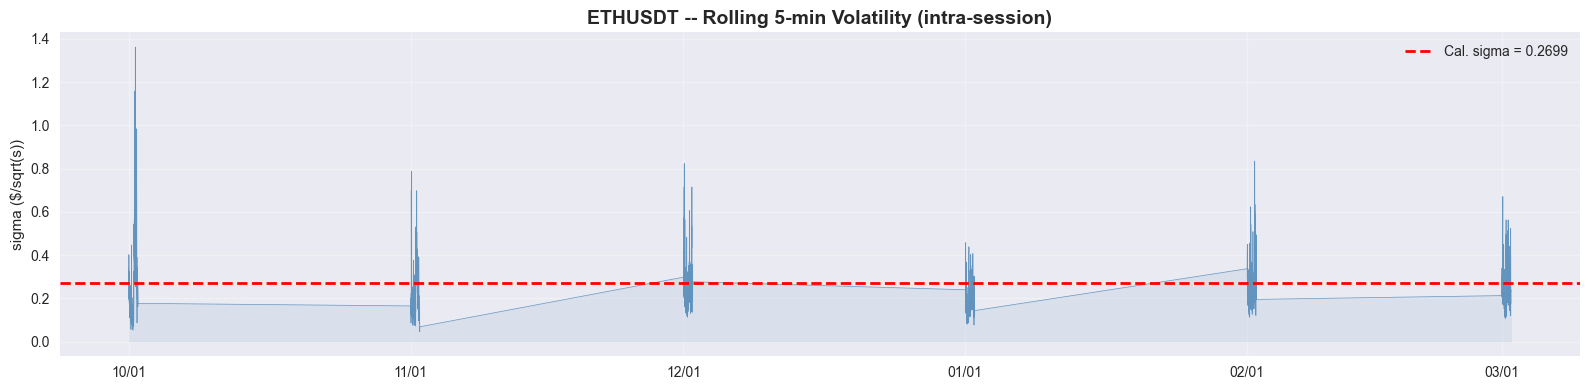

  ETHUSDT: 2.6% > 2x cal., 13.5% < 0.5x cal.


In [43]:
for symbol in SYMBOLS:
    mid = all_mid[symbol]
    sigma = all_params[symbol]["sigma"]
    rolling_sigma = rolling_sigma_by_session(mid, window=300)
    rolling_1min = rolling_sigma.resample("1min").mean().dropna()

    fig, ax = plt.subplots(figsize=(16, 4))
    ax.plot(rolling_1min.index, rolling_1min.values, lw=0.5, alpha=0.8, color="steelblue")
    ax.axhline(sigma, color="red", ls="--", lw=2, label=f"Cal. sigma = {sigma:.4f}")
    ax.fill_between(rolling_1min.index, 0, rolling_1min.values, alpha=0.1, color="steelblue")
    ax.set_title(f"{symbol} -- Rolling 5-min Volatility (intra-session)",
                 fontsize=14, fontweight="bold")
    ax.set_ylabel("sigma ($/sqrt(s))")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m/%d"))
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    pct_above = (rolling_sigma > 2 * sigma).mean() * 100
    pct_below = (rolling_sigma < 0.5 * sigma).mean() * 100
    print(f"  {symbol}: {pct_above:.1f}% > 2x cal., {pct_below:.1f}% < 0.5x cal.")

### A6. Trade intensity and LOB snapshot frequency

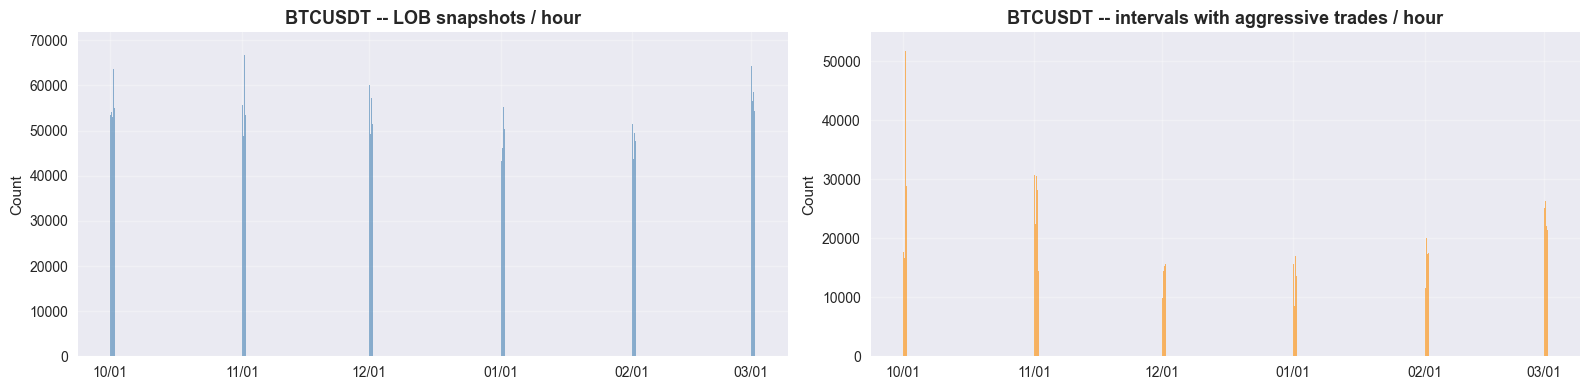

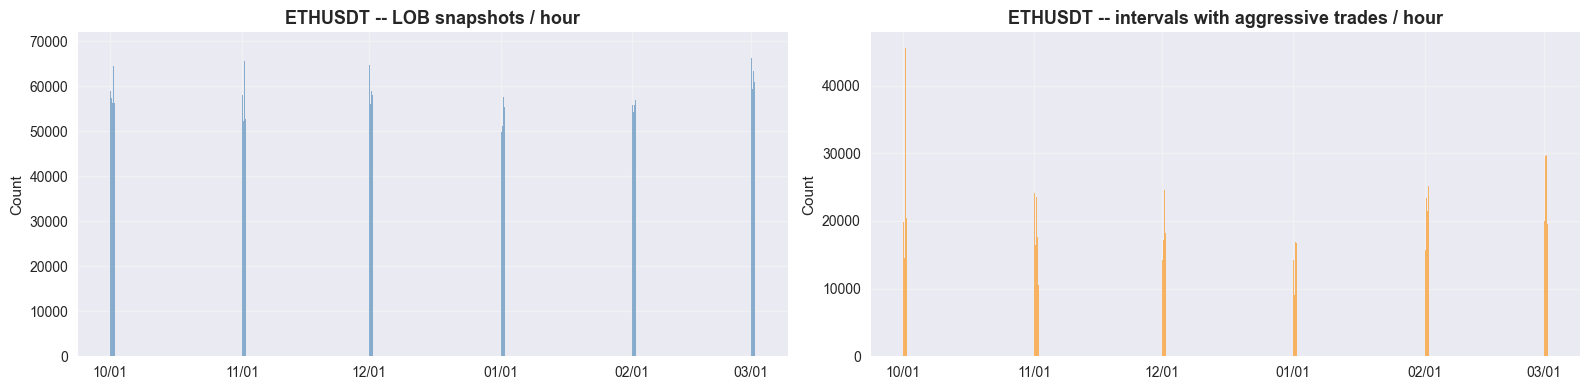

In [44]:
for symbol in SYMBOLS:
    if symbol not in all_intervals:
        continue
    iv = all_intervals[symbol]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))

    snaps_h = iv.set_index("timestamp").resample("1h").size()
    ax1.bar(snaps_h.index, snaps_h.values, width=1/24, alpha=0.6, color="steelblue")
    ax1.set_title(f"{symbol} -- LOB snapshots / hour", fontsize=13, fontweight="bold")
    ax1.set_ylabel("Count")
    ax1.xaxis.set_major_formatter(mdates.DateFormatter("%m/%d"))
    ax1.grid(True, alpha=0.3)

    has_trade = iv["max_buy_price"].notna() | iv["min_sell_price"].notna()
    trades_h = has_trade.groupby(iv["timestamp"].dt.floor("1h")).sum()
    ax2.bar(trades_h.index, trades_h.values, width=1/24, alpha=0.6, color="darkorange")
    ax2.set_title(f"{symbol} -- intervals with aggressive trades / hour",
                  fontsize=13, fontweight="bold")
    ax2.set_ylabel("Count")
    ax2.xaxis.set_major_formatter(mdates.DateFormatter("%m/%d"))
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

---
# Part B — Empirical Backtest on Real L1 Data

## The real L1 backtest engine

At each LOB interval $[t_i, t_{i+1})$ we:

1. **Observe** current inventory $n$ and interval data (mid, half-spread,
   aggressive trade extremes).
2. **Compute** strategy quotes $\delta^b_t(n)$, $\delta^a_t(n)$.
3. **Check passivity**: quote is passive only if $\delta \ge \text{half-spread}_i$.
4. **Check hit**: ask filled if `max_buy_price` $\ge$ `mid + da`;
   bid filled if `min_sell_price` $\le$ `mid - db`.
5. **Update** cash and inventory.

**Units convention**:
- Inventory is in **lots** ($n \in \{-Q, \dots, Q\}$).
- Cash is in **USD**.
- Each fill trades `lot_size` units of the asset at the quote price.
- Mark-to-market: $\text{MtM} = X + n \times \text{lot\_size} \times \text{mid}$.
- `Delta` (from calibration) is the **notional value** of one lot, used only
  by the ODE solver for the Guéant model.  It is **not** used as trade size.

Within each L1 interval, fills are detected from aggressive trade extremes.
If both sides are reached in the same interval, both quotes are treated as
filled.  This is an approximation induced by interval aggregation and lack
of queue-level event ordering.

In [45]:
@dataclass
class EmpiricalBtResult:
    '''Result from a single empirical backtest window.'''
    timestamps: np.ndarray
    mid_prices: np.ndarray
    inventory: np.ndarray
    cash: np.ndarray
    mtm: np.ndarray
    n_bid_fills: int
    n_ask_fills: int
    n_bid_passive: int
    n_ask_passive: int
    delta_bid_posted: np.ndarray
    delta_ask_posted: np.ndarray
    market_half_spread: np.ndarray
    fees_paid: float
    strategy: str
    gamma: float
    symbol: str

    @property
    def pnl(self):
        return self.mtm[-1]

    @property
    def total_fills(self):
        return self.n_bid_fills + self.n_ask_fills

    @property
    def final_inventory(self):
        return int(self.inventory[-1])

    @property
    def bid_passive_rate(self):
        N = len(self.delta_bid_posted)
        return self.n_bid_passive / N if N > 0 else 0.0

    @property
    def ask_passive_rate(self):
        N = len(self.delta_ask_posted)
        return self.n_ask_passive / N if N > 0 else 0.0


def run_backtest_real_lob(
    intervals: pd.DataFrame,
    params: dict,
    gamma: float,
    strategy: str = "optimal",
    maker_fee: float = 0.0001,
    symbol: str = "",
) -> EmpiricalBtResult:
    '''Run a deterministic backtest on real L1 interval data.

    Parameters
    ----------
    intervals : DataFrame from build_interval_table (NB11)
    params : dict with sigma, A, k, Delta, Q, lot_size
    gamma : risk aversion
    strategy : "optimal", "naive", or "closed_form"
    maker_fee : proportional fee (1 bps = 0.0001)
    '''
    sigma, A, k = params["sigma"], params["A"], params["k"]
    Delta, Q = params["Delta"], int(params["Q"])
    lot_size = params["lot_size"]
    xi = gamma

    N = len(intervals)
    T_total = float(intervals["dt"].sum())

    # Pre-compute quote tables from Gueant ODE
    N_t_ode = max(300, int(T_total))
    sol = solve_general(params, gamma, T_total, xi=xi, N_t=N_t_ode)
    db_table = sol["delta_bid"]  # shape (N_t_ode+1, 2Q+1)
    da_table = sol["delta_ask"]

    if strategy == "naive":
        half_spread_naive = db_table[0, Q]  # symmetric at t=0, q=0

    if strategy == "closed_form":
        n_arr = np.arange(-Q, Q + 1)
        db_cf, da_cf = approx_quotes(n_arr, params, gamma, xi=xi)

    # Extract arrays
    mids = intervals["mid"].values
    half_spreads = intervals["half_spread"].values
    max_buy = intervals["max_buy_price"].values
    min_sell = intervals["min_sell_price"].values
    dts = intervals["dt"].values
    timestamps = intervals["timestamp"].values

    # State arrays
    inventory = np.zeros(N + 1, dtype=int)
    cash_arr = np.zeros(N + 1)
    mtm_arr = np.zeros(N + 1)
    db_posted = np.full(N, np.nan)
    da_posted = np.full(N, np.nan)

    n = 0
    X = 0.0
    n_bid = 0
    n_ask = 0
    n_bid_passive = 0
    n_ask_passive = 0
    fees = 0.0

    # Cumulative time for ODE index mapping
    cum_t = np.cumsum(dts)
    cum_t = np.insert(cum_t, 0, 0.0)

    for i in range(N):
        mid_i = mids[i]
        hs_i = half_spreads[i]

        # Map to ODE time index
        t_frac = cum_t[i] / T_total if T_total > 0 else 0.0
        t_idx = min(int(t_frac * N_t_ode), N_t_ode - 1)
        i_lot = n + Q

        # Compute strategy quotes (distance from mid)
        if strategy == "optimal":
            db = db_table[t_idx, i_lot] if (n < Q and 0 <= i_lot < db_table.shape[1] and np.isfinite(db_table[t_idx, i_lot])) else np.inf
            da = da_table[t_idx, i_lot] if (n > -Q and 0 <= i_lot < da_table.shape[1] and np.isfinite(da_table[t_idx, i_lot])) else np.inf
        elif strategy == "naive":
            db = half_spread_naive if n < Q else np.inf
            da = half_spread_naive if n > -Q else np.inf
        elif strategy == "closed_form":
            db = db_cf[i_lot] if (n < Q and 0 <= i_lot < len(db_cf)) else np.inf
            da = da_cf[i_lot] if (n > -Q and 0 <= i_lot < len(da_cf)) else np.inf
        else:
            raise ValueError(f"Unknown strategy: {strategy}")

        db_posted[i] = db
        da_posted[i] = da

        # Passivity: quote must sit outside the spread to be a passive limit order
        bid_passive = np.isfinite(db) and db >= hs_i
        ask_passive = np.isfinite(da) and da >= hs_i

        if bid_passive:
            n_bid_passive += 1
        if ask_passive:
            n_ask_passive += 1

        bid_price = mid_i - db if bid_passive else np.nan
        ask_price = mid_i + da if ask_passive else np.nan

        # Hit detection from real aggressive flow
        bid_fill = (bid_passive
                    and np.isfinite(min_sell[i])
                    and min_sell[i] <= bid_price)
        ask_fill = (ask_passive
                    and np.isfinite(max_buy[i])
                    and max_buy[i] >= ask_price)

        # Execute fills using lot_size (not Delta)
        if bid_fill:
            fee = maker_fee * abs(bid_price) * lot_size
            X -= bid_price * lot_size + fee
            n += 1
            n = min(n, Q)
            n_bid += 1
            fees += fee

        if ask_fill:
            fee = maker_fee * abs(ask_price) * lot_size
            X += ask_price * lot_size - fee
            n -= 1
            n = max(n, -Q)
            n_ask += 1
            fees += fee

        inventory[i + 1] = n
        cash_arr[i + 1] = X
        mtm_arr[i + 1] = X + n * lot_size * mid_i

    # Final MtM
    mtm_arr[-1] = cash_arr[-1] + inventory[-1] * lot_size * mids[-1]

    return EmpiricalBtResult(
        timestamps=timestamps,
        mid_prices=mids,
        inventory=inventory,
        cash=cash_arr,
        mtm=mtm_arr,
        n_bid_fills=n_bid,
        n_ask_fills=n_ask,
        n_bid_passive=n_bid_passive,
        n_ask_passive=n_ask_passive,
        delta_bid_posted=db_posted,
        delta_ask_posted=da_posted,
        market_half_spread=half_spreads.copy(),
        fees_paid=fees,
        strategy=strategy,
        gamma=gamma,
        symbol=symbol,
    )


print("run_backtest_real_lob() defined.")
print(f"  Units: cash in USD, inventory in lots, fills use lot_size")

run_backtest_real_lob() defined.
  Units: cash in USD, inventory in lots, fills use lot_size


### B1. Single-window path analysis

We pick a representative ~1h window per symbol and run all three strategies.

In [46]:
STRATEGIES = ["optimal", "naive", "closed_form"]
LABELS = {"optimal": "Optimal (ODE)", "naive": "Naive (symmetric)", "closed_form": "Closed-form"}
COLORS = {"optimal": "#00a882", "naive": "#e05050", "closed_form": "#8b5cf6"}

WINDOW_SECONDS = 3600

single_window_results = {}

for symbol in SYMBOLS:
    if symbol not in all_intervals:
        continue
    iv = all_intervals[symbol]
    params = all_params[symbol]

    # Pick middle of dataset
    mid_ts = iv["timestamp"].iloc[len(iv) // 2]
    end_ts = mid_ts + pd.Timedelta(seconds=WINDOW_SECONDS)
    window = iv[(iv["timestamp"] >= mid_ts) & (iv["timestamp"] < end_ts)].copy()

    if len(window) < 100:
        print(f"  {symbol}: window too small ({len(window)} intervals), skipping")
        continue

    actual_span = (window["timestamp"].max() - window["timestamp"].min()).total_seconds()
    print(f"\n{symbol} single-window: {mid_ts} -> +{actual_span:.0f}s")
    print(f"  {len(window):,} intervals")

    single_window_results[symbol] = {}
    for strat in STRATEGIES:
        res = run_backtest_real_lob(
            window, params, DEFAULT_GAMMA, strategy=strat,
            maker_fee=0.0001, symbol=symbol,
        )
        single_window_results[symbol][strat] = res
        print(f"  {LABELS[strat]:20s}: PnL={res.pnl:+.6f} $, "
              f"fills={res.total_fills} (bid={res.n_bid_fills}, ask={res.n_ask_fills}), "
              f"inv_T={res.final_inventory:+d}, "
              f"passive bid={res.bid_passive_rate:.0%} ask={res.ask_passive_rate:.0%}")


BTCUSDT single-window: 2024-12-01 02:21:01.520000 -> +3600s
  59,254 intervals
  Optimal (ODE)       : PnL=+0.368681 $, fills=4 (bid=4, ask=0), inv_T=+4, passive bid=27% ask=0%
  Naive (symmetric)   : PnL=-0.522682 $, fills=81 (bid=39, ask=42), inv_T=-3, passive bid=86% ask=87%
  Closed-form         : PnL=+1.110338 $, fills=4 (bid=4, ask=0), inv_T=+4, passive bid=63% ask=0%

ETHUSDT single-window: 2024-12-01 00:33:49.482000 -> +3600s
  64,421 intervals
  Optimal (ODE)       : PnL=-1.142620 $, fills=16 (bid=10, ask=6), inv_T=+4, passive bid=1% ask=1%
  Naive (symmetric)   : PnL=-19.406058 $, fills=2754 (bid=1375, ask=1379), inv_T=-4, passive bid=83% ask=83%
  Closed-form         : PnL=-1.142650 $, fills=16 (bid=10, ask=6), inv_T=+4, passive bid=1% ask=1%


### B2. Sample path visualisation

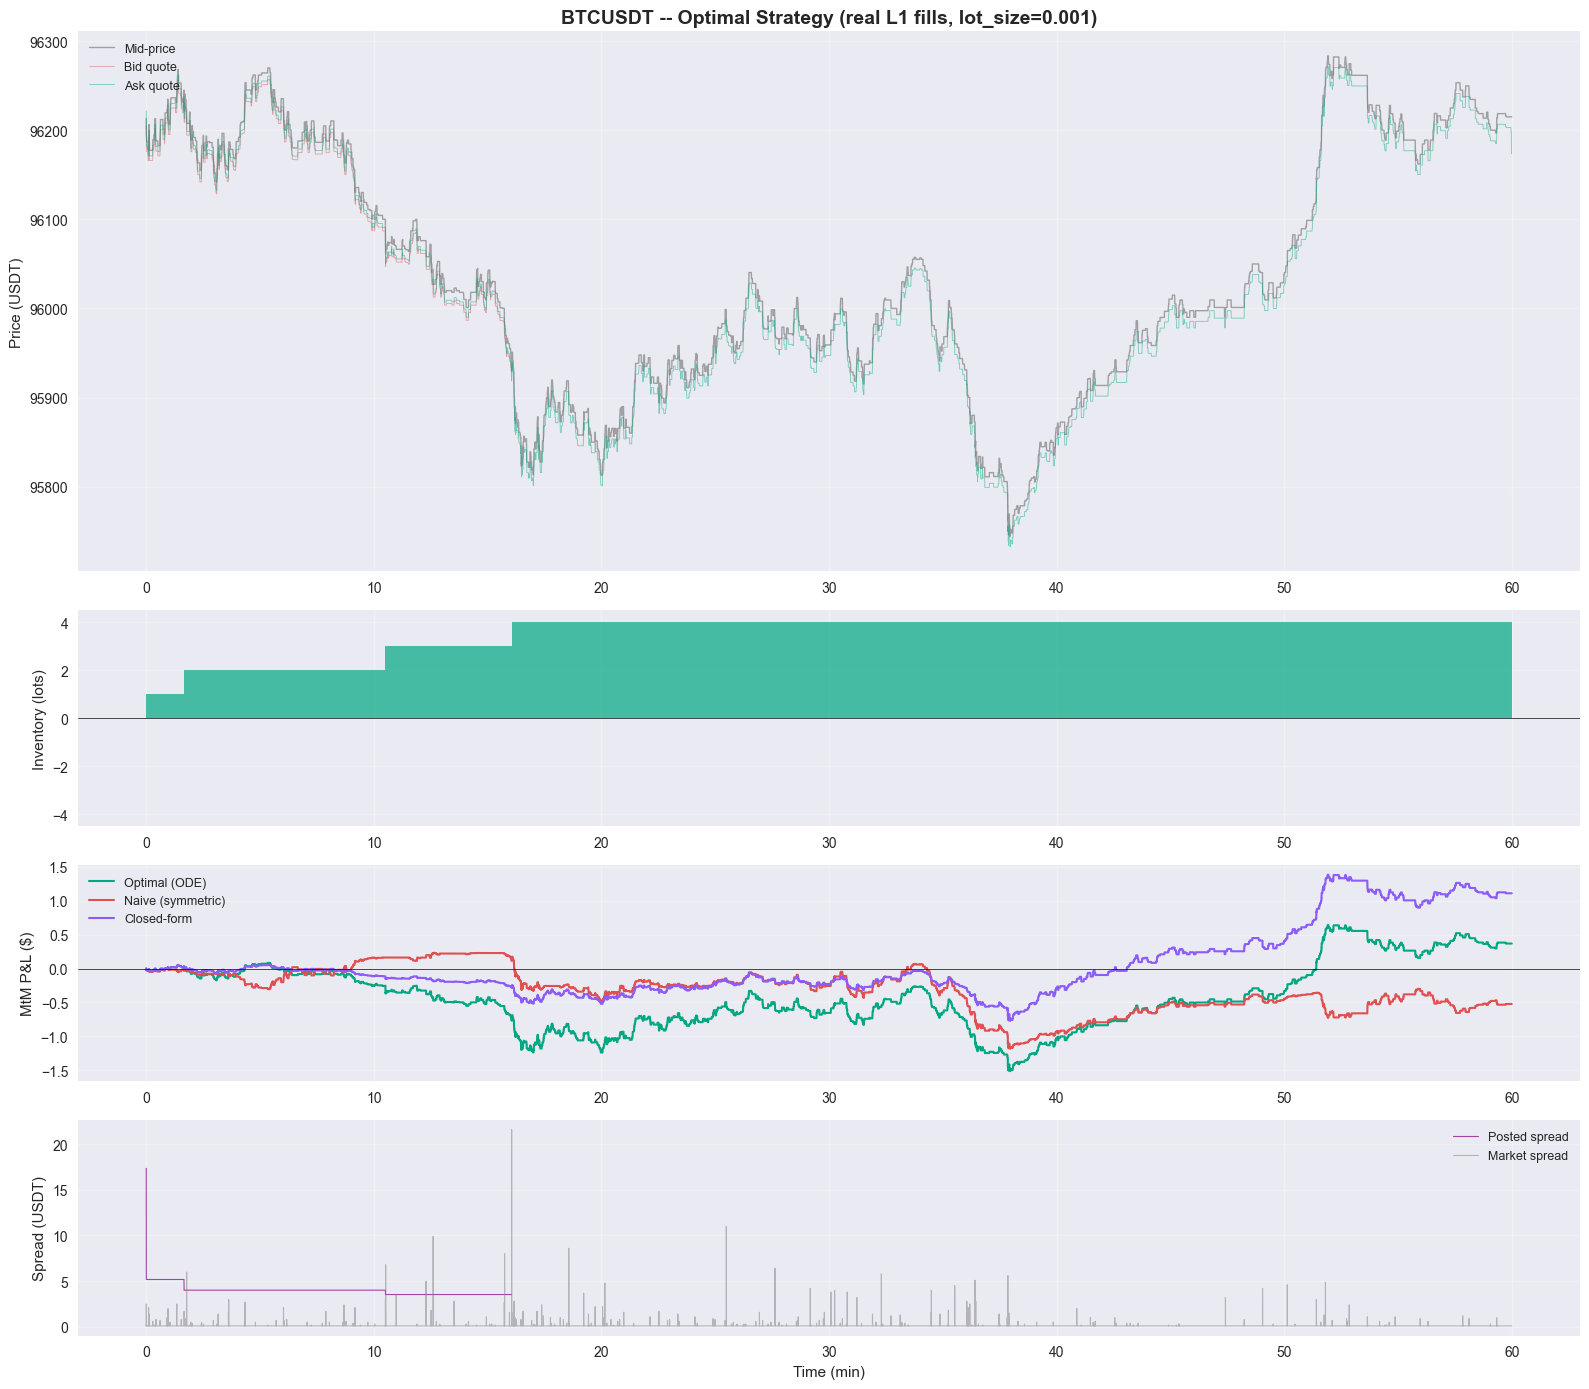

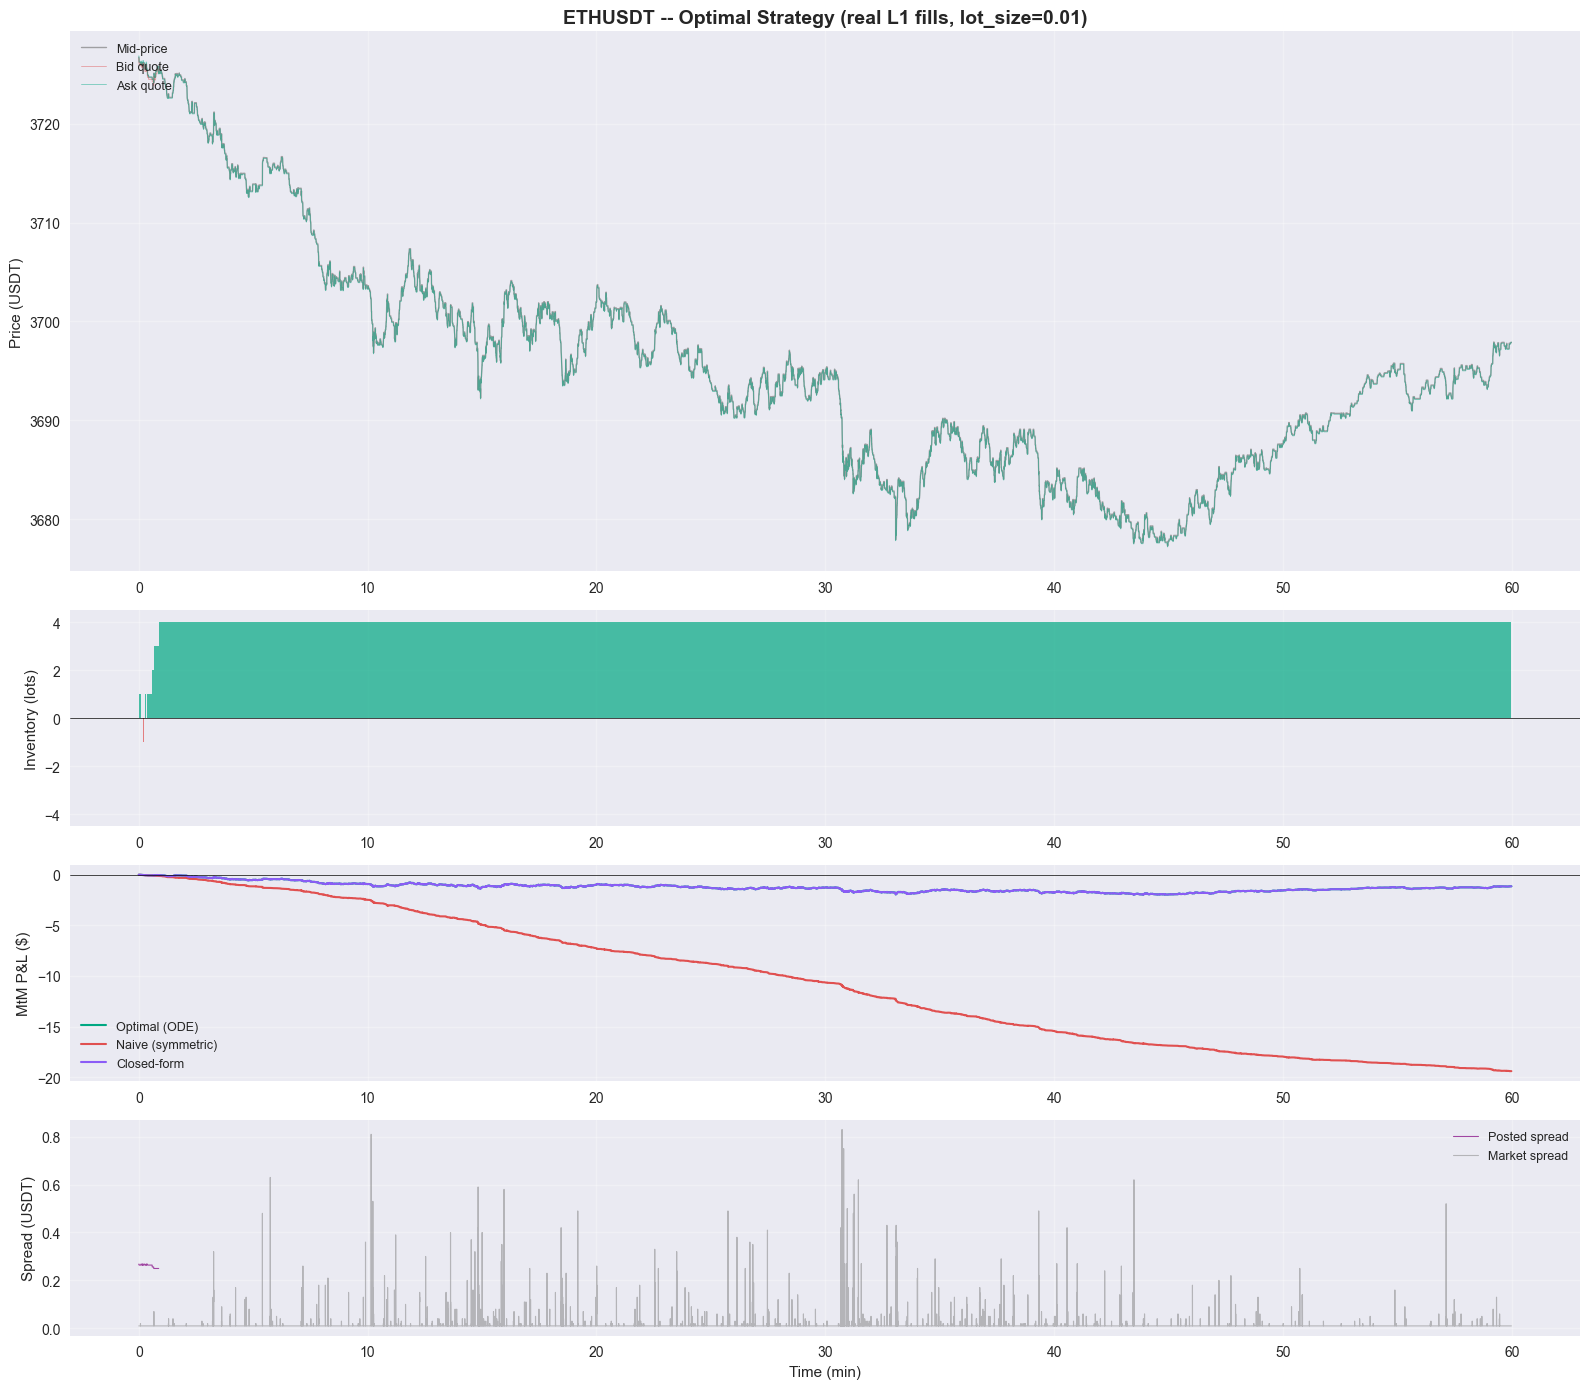

In [47]:
for symbol in SYMBOLS:
    if symbol not in single_window_results:
        continue

    res_opt = single_window_results[symbol]["optimal"]

    fig, axes = plt.subplots(4, 1, figsize=(16, 14),
                             gridspec_kw={"height_ratios": [3, 1.2, 1.2, 1.2]})

    N = len(res_opt.timestamps)
    t_min = np.arange(N) * (res_opt.timestamps[-1] - res_opt.timestamps[0]).astype("timedelta64[s]").astype(float) / (60.0 * (N - 1)) if N > 1 else np.zeros(N)

    # Price + quotes
    ax = axes[0]
    ax.plot(t_min, res_opt.mid_prices, lw=1, color="gray", alpha=0.7, label="Mid-price")
    bid_p = res_opt.mid_prices - res_opt.delta_bid_posted
    ask_p = res_opt.mid_prices + res_opt.delta_ask_posted
    ax.plot(t_min, bid_p, lw=0.6, color="#e05050", alpha=0.5, label="Bid quote")
    ax.plot(t_min, ask_p, lw=0.6, color="#00a882", alpha=0.5, label="Ask quote")
    ax.set_title(f"{symbol} -- Optimal Strategy (real L1 fills, lot_size={all_params[symbol]['lot_size']})",
                 fontsize=14, fontweight="bold")
    ax.set_ylabel("Price (USDT)")
    ax.legend(fontsize=9, loc="upper left")
    ax.grid(True, alpha=0.3)

    # Inventory
    ax = axes[1]
    inv_plot = res_opt.inventory[1:]
    Q = all_params[symbol]["Q"]
    colors_inv = ["#00a882" if v >= 0 else "#e05050" for v in inv_plot]
    bar_w = t_min[1] - t_min[0] if len(t_min) > 1 else 0.01
    ax.bar(t_min, inv_plot.astype(float), width=bar_w, color=colors_inv, alpha=0.7)
    ax.set_ylabel("Inventory (lots)")
    ax.set_ylim(-Q - 0.5, Q + 0.5)
    ax.axhline(0, color="k", lw=0.5)
    ax.grid(True, alpha=0.3)

    # MtM for all strategies
    ax = axes[2]
    for strat in STRATEGIES:
        res = single_window_results[symbol][strat]
        print(symbol, strat, res.pnl)
        ax.plot(t_min, res.mtm[1:], lw=1.5, color=COLORS[strat], label=LABELS[strat])
    ax.set_ylabel("MtM P&L ($)")
    ax.axhline(0, color="k", lw=0.5)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # Posted spread vs market spread
    ax = axes[3]
    spread_posted = res_opt.delta_bid_posted + res_opt.delta_ask_posted
    ax.plot(t_min, spread_posted, lw=0.8, color="purple", alpha=0.7, label="Posted spread")
    ax.plot(t_min, 2 * res_opt.market_half_spread, lw=0.8, color="gray", alpha=0.5, label="Market spread")
    ax.set_xlabel("Time (min)")
    ax.set_ylabel("Spread (USDT)")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

### B3. Single-window summary table

In [48]:
rows = []
for symbol in SYMBOLS:
    if symbol not in single_window_results:
        continue
    for strat in STRATEGIES:
        res = single_window_results[symbol][strat]
        rows.append({
            "Symbol": symbol,
            "Strategy": LABELS[strat],
            "P&L ($)": f"{res.pnl:+.6f}",
            "Bid fills": res.n_bid_fills,
            "Ask fills": res.n_ask_fills,
            "Total fills": res.total_fills,
            "Final inv": f"{res.final_inventory:+d}",
            "Bid passive%": f"{res.bid_passive_rate:.0%}",
            "Ask passive%": f"{res.ask_passive_rate:.0%}",
            "Fees ($)": f"{res.fees_paid:.6f}",
        })

summary_single = pd.DataFrame(rows)
display(summary_single)

print("\nPassivity diagnostic: if passive rate < 50%, the strategy's quotes")
print("are often inside the spread and thus not executable as limit orders.")

,Symbol,Strategy,P&L ($),Bid fills,Ask fills,Total fills,Final inv,Bid passive%,Ask passive%,Fees ($)
0,BTCUSDT,Optimal (ODE),+0.368681,4,0,4,+4,27%,0%,0.038445
1,BTCUSDT,Naive (symmetric),-0.522682,39,42,81,-3,86%,87%,0.777782
2,BTCUSDT,Closed-form,+1.110338,4,0,4,+4,63%,0%,0.038371
3,ETHUSDT,Optimal (ODE),-1.142620,10,6,16,+4,1%,1%,0.059611
4,ETHUSDT,Naive (symmetric),-19.406058,1375,1379,2754,-4,83%,83%,10.173957
5,ETHUSDT,Closed-form,-1.142650,10,6,16,+4,1%,1%,0.059611



Passivity diagnostic: if passive rate < 50%, the strategy's quotes
are often inside the spread and thus not executable as limit orders.


---
# Part C — Real L1 Fills vs Synthetic Poisson Fills

We compare the empirical backtest (real aggressive-flow hit detection) with the
traditional Poisson simulation engine on the **same** price path.

This tests: does the Poisson model $\Lambda(\delta) = A\,e^{-k\delta}$ produce
similar fill patterns to what actually happens on the L1 order book?

In [52]:
from market_making.simulation.backtest import BacktestConfig, run_backtest as run_backtest_poisson

comparison_results = {}

for symbol in SYMBOLS:
    if symbol not in all_intervals:
        continue
    iv = all_intervals[symbol]
    params = all_params[symbol]

    # Same window as Part B
    mid_ts = iv["timestamp"].iloc[len(iv) // 2]
    end_ts = mid_ts + pd.Timedelta(seconds=WINDOW_SECONDS)
    window = iv[(iv["timestamp"] >= mid_ts) & (iv["timestamp"] < end_ts)].copy()

    if len(window) < 100:
        continue

    mid_arr = window["mid"].values

    comparison_results[symbol] = {}
    comparison_results[symbol]["empirical"] = single_window_results[symbol]

    # Poisson simulation (500 MC paths on same mid-prices)
    poisson_results = {}
    for strat in ["optimal", "naive"]:
        cfg = BacktestConfig(
            params=params, gamma=DEFAULT_GAMMA, T=float(window["dt"].sum()),
            N_t=len(window), N_sim=500, seed=42, strategy=strat,
            mid_prices=mid_arr,
        )
        poisson_results[strat] = run_backtest_poisson(cfg)
    comparison_results[symbol]["poisson"] = poisson_results

    print(f"\n{symbol} comparison (same window):")
    for strat in ["optimal", "naive"]:
        emp = single_window_results[symbol][strat]
        poi = poisson_results[strat]
        print(f"  {LABELS[strat]:20s}")
        print(f"    Empirical:  PnL={emp.pnl:+.6f} $, fills={emp.total_fills}")
        print(f"    Poisson MC: E[PnL]={poi.mean_pnl:+.4f} $, E[fills]={poi.mean_fills:.1f}")
    print(f"  Note: Poisson engine uses Delta={params['Delta']:.2f} as trade size,")
    print(f"        empirical engine uses lot_size={params['lot_size']}.")
    print(f"        P&L scales differ -- compare fill counts and Sharpe, not raw P&L.")

KeyboardInterrupt: 

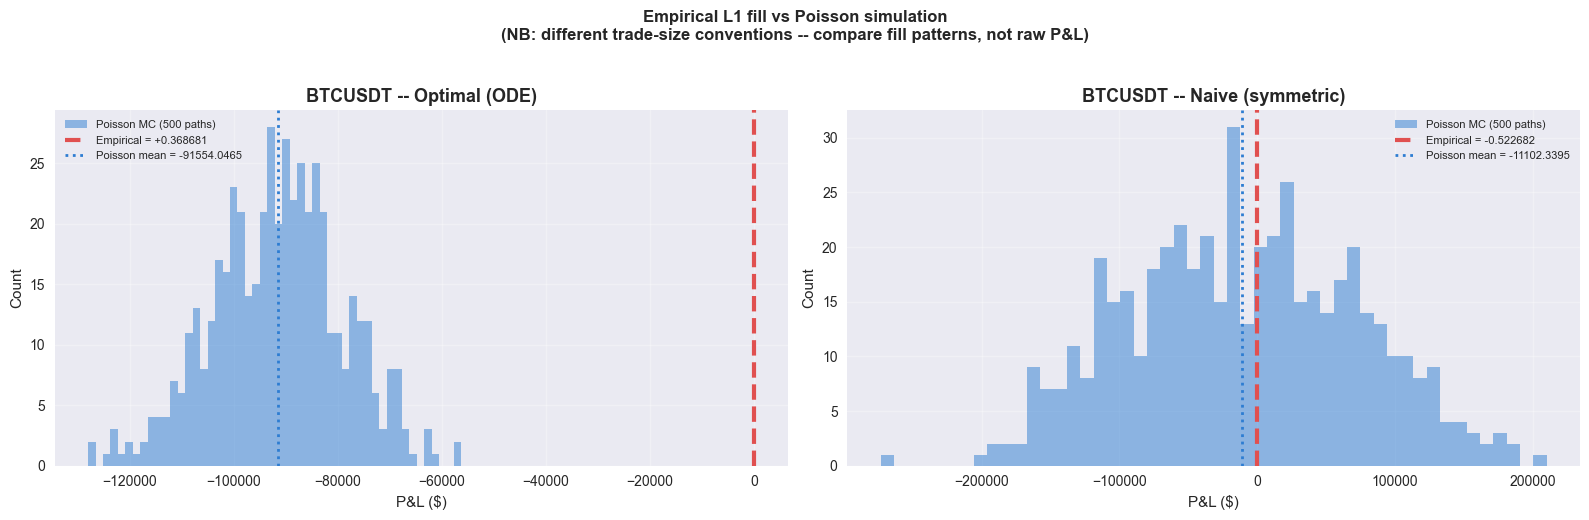

KeyError: 'poisson'

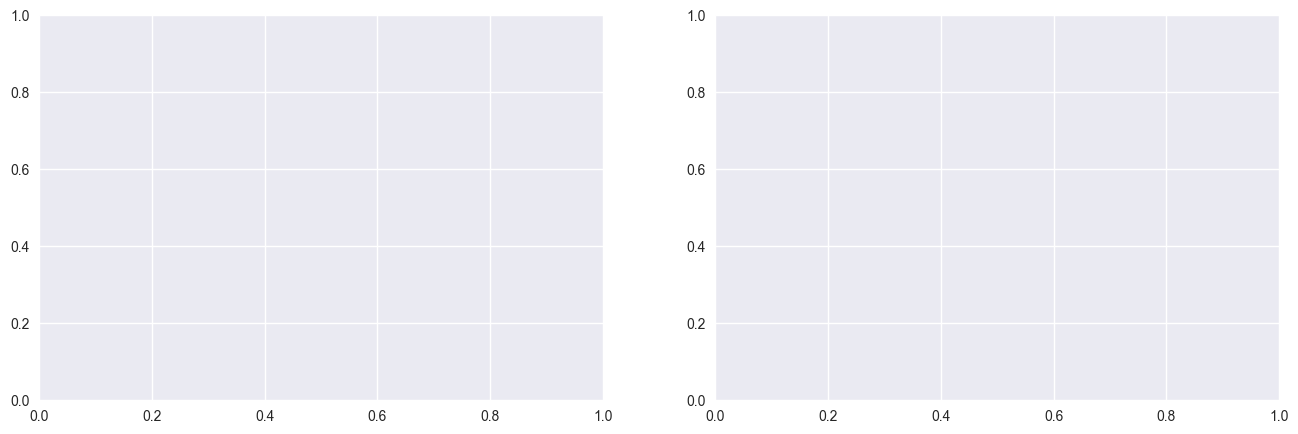

In [50]:
for symbol in SYMBOLS:
    if symbol not in comparison_results:
        continue
    cr = comparison_results[symbol]

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    for col, strat in enumerate(["optimal", "naive"]):
        ax = axes[col]
        poi = cr["poisson"][strat]
        emp_pnl = cr["empirical"][strat].pnl

        ax.hist(poi.pnl, bins=50, alpha=0.5, color="#2d7dd2", label="Poisson MC (500 paths)")
        ax.axvline(emp_pnl, color="#e05050", lw=3, ls="--",
                   label=f"Empirical = {emp_pnl:+.6f}")
        ax.axvline(poi.mean_pnl, color="#2d7dd2", lw=2, ls=":",
                   label=f"Poisson mean = {poi.mean_pnl:+.4f}")
        ax.set_title(f"{symbol} -- {LABELS[strat]}", fontsize=13, fontweight="bold")
        ax.set_xlabel("P&L ($)")
        ax.set_ylabel("Count")
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    plt.suptitle("Empirical L1 fill vs Poisson simulation\n"
                 "(NB: different trade-size conventions -- compare fill patterns, not raw P&L)",
                 fontsize=12, fontweight="bold", y=1.03)
    plt.tight_layout()
    plt.show()

---
# Part D — Rolling Multi-Window Backtest

The main evaluation section.  We run the empirical L1 backtest on many
consecutive real windows across the dataset.  Each window yields one
deterministic P&L per strategy.

Metrics stored per window: P&L, fills (bid/ask), final inventory,
mean absolute inventory, mean posted spread, mean market half-spread, fees.

In [ ]:
WINDOW_MINUTES = 30
STRIDE_MINUTES = 15
MAX_WINDOWS = 200

rolling_all = {}

for symbol in SYMBOLS:
    if symbol not in all_intervals:
        continue
    iv = all_intervals[symbol]
    params = all_params[symbol]

    print(f"\n{'='*55}\nRolling backtest: {symbol}\n{'='*55}")

    t_min_ts = iv["timestamp"].min()
    t_max_ts = iv["timestamp"].max()

    starts = pd.date_range(
        t_min_ts + pd.Timedelta(minutes=5),
        t_max_ts - pd.Timedelta(minutes=WINDOW_MINUTES + 5),
        freq=f"{STRIDE_MINUTES}min",
    )
    if len(starts) > MAX_WINDOWS:
        step = len(starts) // MAX_WINDOWS
        starts = starts[::step][:MAX_WINDOWS]

    print(f"  {len(starts)} windows x {WINDOW_MINUTES}min, stride {STRIDE_MINUTES}min")

    results_list = []
    for i, start in enumerate(starts):
        end = start + pd.Timedelta(minutes=WINDOW_MINUTES)
        w = iv[(iv["timestamp"] >= start) & (iv["timestamp"] < end)].copy()

        if len(w) < 50:
            continue

        # Per-session returns for realised sigma
        mid_w = w["mid"].values
        ret_w = np.diff(mid_w)

        row = {
            "start": start,
            "n_intervals": len(w),
            "mid_price": float(np.mean(mid_w)),
            "sigma_realised": float(np.std(ret_w)) if len(ret_w) > 1 else 0.0,
            "mean_half_spread": float(w["half_spread"].mean()),
        }

        for strat in STRATEGIES:
            try:
                res = run_backtest_real_lob(
                    w, params, DEFAULT_GAMMA, strategy=strat,
                    maker_fee=0.0001, symbol=symbol,
                )
                row[f"{strat}_pnl"] = res.pnl
                row[f"{strat}_fills"] = res.total_fills
                row[f"{strat}_bid_fills"] = res.n_bid_fills
                row[f"{strat}_ask_fills"] = res.n_ask_fills
                row[f"{strat}_inv_T"] = res.final_inventory
                row[f"{strat}_abs_inv_mean"] = float(np.mean(np.abs(res.inventory)))
                row[f"{strat}_fees"] = res.fees_paid
                row[f"{strat}_spread_mean"] = float(np.nanmean(
                    res.delta_bid_posted + res.delta_ask_posted))
            except Exception as e:
                row[f"{strat}_pnl"] = np.nan

        results_list.append(row)

        if (i + 1) % 50 == 0 or i == len(starts) - 1:
            print(f"  [{i+1}/{len(starts)}] done")

    roll_df = pd.DataFrame(results_list)
    rolling_all[symbol] = roll_df
    print(f"  Completed: {len(roll_df)} windows")

### D1. Rolling P&L comparison

In [ ]:
for symbol in SYMBOLS:
    if symbol not in rolling_all:
        continue
    roll_df = rolling_all[symbol]

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    # P&L over time
    ax = axes[0, 0]
    for strat in STRATEGIES:
        col = f"{strat}_pnl"
        if col in roll_df:
            ax.plot(roll_df["start"], roll_df[col], "o-", ms=2, lw=0.8,
                    color=COLORS[strat], label=LABELS[strat], alpha=0.7)
    ax.axhline(0, color="k", lw=0.5)
    ax.set_title(f"{symbol} -- P&L per Window", fontsize=13, fontweight="bold")
    ax.set_ylabel("P&L ($)")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m/%d %H:%M"))
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right")

    # P&L boxplot
    ax = axes[0, 1]
    data_box = [roll_df[f"{s}_pnl"].dropna().values for s in STRATEGIES]
    bp = ax.boxplot(data_box, labels=[LABELS[s] for s in STRATEGIES],
                    patch_artist=True, widths=0.6)
    for patch, strat in zip(bp["boxes"], STRATEGIES):
        patch.set_facecolor(COLORS[strat])
        patch.set_alpha(0.5)
    ax.set_title("P&L Distribution Across Windows", fontsize=13, fontweight="bold")
    ax.set_ylabel("P&L ($)")
    ax.grid(True, alpha=0.3)

    # P&L vs realised sigma
    ax = axes[1, 0]
    for strat in STRATEGIES:
        col = f"{strat}_pnl"
        if col in roll_df:
            ax.scatter(roll_df["sigma_realised"], roll_df[col],
                       s=15, alpha=0.5, color=COLORS[strat], label=LABELS[strat])
    ax.set_title("P&L vs Realised Volatility", fontsize=13, fontweight="bold")
    ax.set_xlabel("sigma_realised ($/sqrt(s))")
    ax.set_ylabel("P&L ($)")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # Win rate: optimal vs naive
    ax = axes[1, 1]
    valid = roll_df[["optimal_pnl", "naive_pnl"]].dropna()
    opt_wins = (valid["optimal_pnl"] > valid["naive_pnl"]).sum()
    naive_wins = (valid["naive_pnl"] > valid["optimal_pnl"]).sum()
    ties = len(valid) - opt_wins - naive_wins
    total = len(valid)
    ax.bar(["Optimal wins", "Naive wins", "Tie"],
           [opt_wins, naive_wins, ties],
           color=["#00a882", "#e05050", "gray"], alpha=0.7)
    ax.set_title(f"Win Rate: {opt_wins}/{total} = {opt_wins/max(total,1):.0%}",
                 fontsize=13, fontweight="bold")
    ax.set_ylabel("# Windows")
    ax.grid(True, alpha=0.3)

    plt.suptitle(f"{symbol} -- Rolling Empirical Backtest ({len(roll_df)} windows)",
                 fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()

### D2. Cumulative P&L across windows

In [ ]:
for symbol in SYMBOLS:
    if symbol not in rolling_all:
        continue
    roll_df = rolling_all[symbol]

    fig, ax = plt.subplots(figsize=(16, 5))

    for strat in STRATEGIES:
        col = f"{strat}_pnl"
        if col in roll_df:
            cum = roll_df[col].fillna(0).cumsum()
            ax.plot(roll_df["start"], cum, lw=2, color=COLORS[strat], label=LABELS[strat])

    ax.axhline(0, color="k", lw=0.5)
    ax.set_title(f"{symbol} -- Cumulative P&L (rolling windows)", fontsize=14, fontweight="bold")
    ax.set_ylabel("Cumulative P&L ($)")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m/%d %H:%M"))
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

### D3. Rolling metrics summary

In [ ]:
for symbol in SYMBOLS:
    if symbol not in rolling_all:
        continue
    roll_df = rolling_all[symbol]

    print(f"\n{'='*70}")
    print(f"  {symbol} -- Rolling Backtest Summary ({len(roll_df)} windows)")
    print(f"{'='*70}")
    print(f"  {'Strategy':<20s} {'Mean PnL':>10s} {'Std PnL':>10s} {'Sharpe':>8s} "
          f"{'Win%':>6s} {'Med Fills':>10s} {'Avg |inv|':>10s}")
    print(f"  {'_'*80}")

    valid = roll_df[["optimal_pnl", "naive_pnl"]].dropna()

    for strat in STRATEGIES:
        col = f"{strat}_pnl"
        fcol = f"{strat}_fills"
        icol = f"{strat}_abs_inv_mean"
        if col not in roll_df:
            continue
        pnls = roll_df[col].dropna()
        fills = roll_df[fcol].dropna() if fcol in roll_df else pd.Series([0])
        abs_inv = roll_df[icol].dropna() if icol in roll_df else pd.Series([0])
        mean_p = pnls.mean()
        std_p = pnls.std()
        sharpe = mean_p / std_p if std_p > 0 else 0
        if strat == "optimal":
            win_pct = (valid["optimal_pnl"] > valid["naive_pnl"]).mean() * 100
        elif strat == "naive":
            win_pct = (valid["naive_pnl"] > valid["optimal_pnl"]).mean() * 100
        else:
            win_pct = np.nan
        print(f"  {LABELS[strat]:<20s} {mean_p:>+10.6f} {std_p:>10.6f} {sharpe:>8.3f} "
              f"{win_pct:>5.1f}% {fills.median():>10.0f} {abs_inv.mean():>10.2f}")

---
# Part E — Summary & Dashboard-Ready Export

In [ ]:
EXPORT_DIR = DATA_DIR.parent / "backtest_results"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

for symbol in SYMBOLS:
    if symbol not in rolling_all:
        continue
    roll_df = rolling_all[symbol]
    out_path = EXPORT_DIR / f"rolling_backtest_{symbol}.csv"
    roll_df.to_csv(out_path, index=False)
    print(f"Saved: {out_path}")

print("\nExport complete.")

In [ ]:
print("=" * 70)
print("  EMPIRICAL BACKTEST SUMMARY")
print("=" * 70)

for symbol in SYMBOLS:
    if symbol not in rolling_all:
        continue
    params = all_params[symbol]
    roll_df = rolling_all[symbol]
    valid = roll_df[["optimal_pnl", "naive_pnl"]].dropna()
    opt_wins = (valid["optimal_pnl"] > valid["naive_pnl"]).sum()

    print(f"\n  {symbol}")
    print(f"    sigma={params['sigma']:.4f}, A={params['A']:.4f}, "
          f"k={params['k']:.4f}")
    print(f"    Delta={params['Delta']:.2f}$ (notional), "
          f"lot_size={params['lot_size']} (asset qty)")
    print(f"    gamma = {DEFAULT_GAMMA}")
    print(f"    Windows: {len(roll_df)}")
    print(f"    Optimal beats Naive: {opt_wins}/{len(valid)} "
          f"({opt_wins/max(len(valid),1):.0%})")
    for strat in STRATEGIES:
        col = f"{strat}_pnl"
        if col in roll_df:
            pnls = roll_df[col].dropna()
            std = pnls.std()
            sharpe = pnls.mean() / std if std > 0 else 0
            print(f"    {LABELS[strat]:20s}: mean={pnls.mean():+.6f}, "
                  f"std={std:.6f}, Sharpe={sharpe:.3f}")

print("\n" + "=" * 70)

## Key takeaways

1. **Empirical L1 fills replace Poisson simulation**: fills are deterministic
   given the data and the strategy.  No synthetic randomness on top of real prices.

2. **Rolling windows replace Monte Carlo**: evaluation across many real market
   conditions, not many fake fill draws on one window.

3. **Both BTC and ETH are tested**: same framework, symbol-specific calibration.

4. **lot_size vs Delta**: trade execution uses `lot_size` (asset quantity per
   lot); `Delta` (notional) is used only by the Guéant ODE solver.

## Caveats

- **Queue position is unobserved**: we assume any aggressive trade reaching our
  hypothetical quote price fills us.
- **No partial fills**: each interval is 0 or 1 fill per side.
- **Fee model is stylised**: flat proportional fee, no rebates or funding.
- **Within-interval ordering ignored**: if both bid and ask are hit in the same
  interval, both execute without temporal priority.
- **The ODE solution assumes GBM**: the control policy is computed under the
  paper's assumptions, even though execution uses real data.